In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt
filename = "/Users/miki/Documents/compfin/data/hprice.csv"



In [65]:
data = pd.read_csv(filename, delimiter=";")
data.info()
data.head()




<class 'pandas.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   sale price  546 non-null    int64
 1   lot size    546 non-null    int64
 2   #bedroom    546 non-null    int64
 3   #bath       546 non-null    int64
 4   #stories    546 non-null    int64
 5   driveway    546 non-null    int64
 6   rec room    546 non-null    int64
 7   basement    546 non-null    int64
 8   gas         546 non-null    int64
 9   air cond    546 non-null    int64
 10  #garage     546 non-null    int64
 11  desire loc  546 non-null    int64
dtypes: int64(12)
memory usage: 51.3 KB


,sale price,lot size,#bedroom,#bath,#stories,driveway,rec room,basement,gas,air cond,#garage,desire loc
0,42000,5850,3,1,2,1,0,1,0,0,1,0
1,38500,4000,2,1,1,1,0,0,0,0,0,0
2,49500,3060,3,1,1,1,0,0,0,0,0,0
3,60500,6650,3,1,2,1,1,0,0,0,0,0
4,61000,6360,2,1,1,1,0,0,0,0,0,0


In [ ]:
reg = np.polyfit(data["sale price"], data["#bedroom"], deg=1)
reg.view()
ax=data.plot(kind="scatter", x="sale price", y="#bedroom")
ax.plot(data["sale price"], np.polyval(reg, data["sale price"]), color="red", lw = 2)

In [ ]:

import statsmodels.api as sm
X = data["sale price"]
y = data["#bedroom"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.params
model.predict()[0:10]
print(model.summary())

In [ ]:
multreg = np.polyfit(data["sale price"], data[[:, 2:]], deg=1)
multreg.view()
ax=data.plot(kind="scatter", x="sale price", y="#bedroom")
ax.plot(data["sale price"], np.polyval(reg, data["sale price"]), color="red", lw = 2)


In [72]:
data.columns[1:12] 

Index(['lot size', '#bedroom', '#bath', '#stories', 'driveway', 'rec room',
       'basement', 'gas', 'air cond', '#garage', 'desire loc'],
      dtype='str')

In [69]:

import statsmodels.api as sm 
X = data["sale price"]
Y = data.columns[1:4] 
Y.isna().sum()


np.int64(0)

In [ ]:
X = sm.add_constant(X)
multi_model = sm.OLS(Y, X).fit()
multi_model.params
mu.ti_model.predict()[0:10]
print(multi_model.summary())

<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       266 non-null    str    
 1   SPX Index  266 non-null    float64
 2   DAX Index  266 non-null    float64
dtypes: float64(2), str(1)
memory usage: 6.4 KB


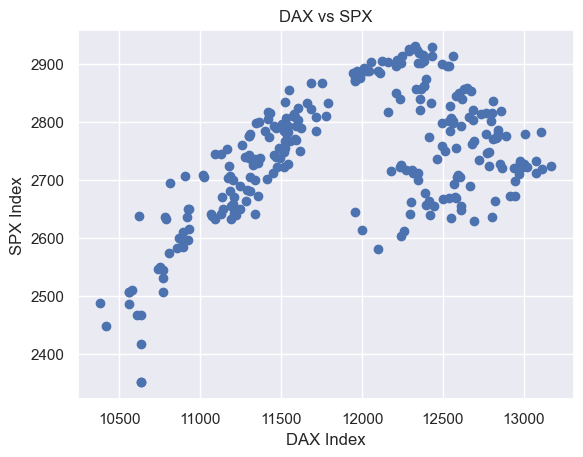

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set()
import matplotlib as mlt
import matplotlib.pyplot as plt
filename1 = "/Users/miki/Documents/compfin/data/dax_spx.csv"
data1 = pd.read_csv(filename1, parse_dates=True, delimiter=',')
data1.info()
plt.scatter(data1["DAX Index"], data1["SPX Index"])
plt.xlabel("DAX Index")
plt.ylabel("SPX Index")
plt.title("DAX vs SPX")
plt.show()



In [102]:
import statsmodels.api as sm
X1 = data1["SPX Index"]
y1 = data1["DAX Index"]
X1 = sm.add_constant(X1)
model1 = sm.OLS(y1, X1).fit()
model1.params
model1.predict()[0:10]
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              DAX Index   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     84.29
Date:                Wed, 20 May 2026   Prob (F-statistic):           1.29e-17
Time:                        01:20:50   Log-Likelihood:                -2088.4
No. Observations:                 266   AIC:                             4181.
Df Residuals:                     264   BIC:                             4188.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3091.8877    960.751      3.218      0.0

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set()
import matplotlib as mlt
import matplotlib.pyplot as plt
filename2 = "/Users/miki/Documents/compfin/data/dax_spx.csv"
data2 = pd.read_csv(filename2, parse_dates=True, delimiter=',')
data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       266 non-null    str    
 1   SPX Index  266 non-null    float64
 2   DAX Index  266 non-null    float64
dtypes: float64(2), str(1)
memory usage: 6.4 KB


In [89]:
dax = data2["DAX Index"]
returns_dax = 100*np.log(dax/dax.shift(1))
returns_dax.dropna(inplace=True)
returns_dax.head()

1   -0.782437
2   -0.371865
3    2.862898
4   -0.520809
5    0.167163
Name: DAX Index, dtype: float64

In [92]:
from arch import arch_model
ret_demeaned = returns_dax - returns_dax.mean()
am = arch_model(ret_demeaned, mean = 'zero')
res = am.fit()
res

Iteration:      1,   Func. Count:      5,   Neg. LLF: 140483503.8002329
Iteration:      2,   Func. Count:     12,   Neg. LLF: 360.50975283397787
Iteration:      3,   Func. Count:     17,   Neg. LLF: 360.01543617219465
Iteration:      4,   Func. Count:     22,   Neg. LLF: 358.5515015218499
Iteration:      5,   Func. Count:     27,   Neg. LLF: 357.83652993673184
Iteration:      6,   Func. Count:     32,   Neg. LLF: 357.8360151513818
Iteration:      7,   Func. Count:     36,   Neg. LLF: 357.83601376994176
Iteration:      8,   Func. Count:     39,   Neg. LLF: 357.8360137699486
Optimization terminated successfully    (Exit mode 0)
            Current function value: 357.83601376994176
            Iterations: 8
            Function evaluations: 39
            Gradient evaluations: 8


                       Zero Mean - GARCH Model Results                        
Dep. Variable:              DAX Index   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.004
Vol Model:                      GARCH   Log-Likelihood:               -357.836
Distribution:                  Normal   AIC:                           721.672
Method:            Maximum Likelihood   BIC:                           732.411
                                        No. Observations:                  265
Date:                Wed, May 20 2026   Df Residuals:                      265
Time:                        00:56:09   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0640      0.142      0.450      0.653 

In [98]:
res.params

omega       0.064023
alpha[1]    0.009327
beta[1]     0.916338
Name: params, dtype: float64

In [100]:
sigmasq_f=[]
tmp=[]
alpha0=res.params.iloc[0]
alpha1=res.params.iloc[1]
beta=res.params.iloc[2]

for i in range(0,251):
    tmp.append((alpha1 + beta)**i)
    
for h in range(1,251):
     sigmasq_f.append(alpha0 * np.sum(tmp[0:h]) + tmp[h-1] * (alpha1 * returns_dax.iloc[-1]**2 \
                                                              + beta * res.conditional_volatility.iloc[-1]**2))
    

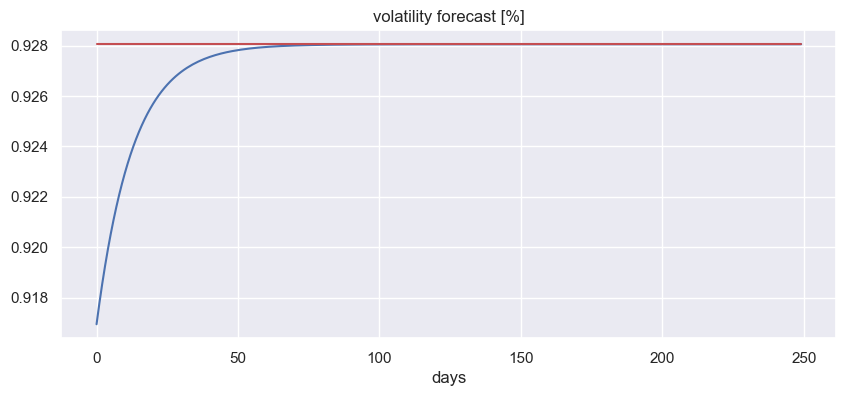

In [101]:
unconditional_vol=np.sqrt(res.params.iloc[0]/(1-res.params.iloc[1]-res.params.iloc[2]))*np.ones(len(sigmasq_f))
plt.figure(figsize=(10, 4))
plt.plot(np.sqrt(sigmasq_f))
plt.plot(unconditional_vol, 'r')
plt.title('volatility forecast [%]')
plt.xlabel('days');